In [3]:
import sys
sys.path.append("/Users/chris/Documents/higs-vision")
import torch
import numpy as np
import json
import copy
import time

from src.data import load_config, load_processed
from src.models import HiggsDNN
from src.train import train, save_training_run

config = load_config("/Users/chris/Documents/higs-vision/config.yaml")
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed(config)

with open("/Users/chris/Documents/higs-vision/results/optuna/best_params.json") as f:
    best = json.load(f)

width = best["hidden_width"]

Loaded processed data from /Users/chris/Documents/higs-vision/data/processed/
  Train: (700000, 28), Val: (150000, 28), Test: (150000, 28)


In [4]:
ensemble_config = copy.deepcopy(config)
ensemble_config["dnn"]["learning_rate"] = best["learning_rate"]
ensemble_config["dnn"]["weight_decay"] = best["weight_decay"]
ensemble_config["dnn"]["batch_size"] = best["batch_size"]
ensemble_config["dnn"]["cosine_annealing"] = best["cosine_annealing"]
ensemble_config["dnn"]["max_epochs"] = 60
ensemble_config["dnn"]["early_stopping_patience"] = 10

In [5]:
print("=" * 60)
print("ENSEMBLE MEMBER 2 (seed 123)")
print("=" * 60)

model2 = HiggsDNN(
    input_dim=28,
    hidden_dims=[width, width // 2, width // 4, width // 8],
    activation=best["activation"],
    dropout_rate=best["dropout"],
    use_batch_norm=best["batch_norm"]
)

model2, history2 = train(
    model2, X_train, y_train, X_val, y_val,
    ensemble_config, seed=123
)

save_training_run(model2, history2, ensemble_config,
                  "/Users/chris/Documents/higs-vision/models/ensemble/member2",
                  seed=123)

ENSEMBLE MEMBER 2 (seed 123)
Epoch   1 | Train Loss: 0.5800 | Val Loss: 0.5372 | Val AUC: 0.8023 | Time: 23.6s
Epoch   2 | Train Loss: 0.5415 | Val Loss: 0.5200 | Val AUC: 0.8171 | Time: 22.1s
Epoch   3 | Train Loss: 0.5301 | Val Loss: 0.5111 | Val AUC: 0.8243 | Time: 21.9s
Epoch   4 | Train Loss: 0.5230 | Val Loss: 0.5053 | Val AUC: 0.8287 | Time: 22.1s
Epoch   5 | Train Loss: 0.5185 | Val Loss: 0.5014 | Val AUC: 0.8321 | Time: 22.6s
Epoch   6 | Train Loss: 0.5148 | Val Loss: 0.5003 | Val AUC: 0.8338 | Time: 23.3s
Epoch   7 | Train Loss: 0.5122 | Val Loss: 0.4966 | Val AUC: 0.8363 | Time: 23.4s
Epoch   8 | Train Loss: 0.5102 | Val Loss: 0.4962 | Val AUC: 0.8367 | Time: 23.3s
Epoch   9 | Train Loss: 0.5084 | Val Loss: 0.4981 | Val AUC: 0.8374 | Time: 22.9s
Epoch  10 | Train Loss: 0.5067 | Val Loss: 0.4927 | Val AUC: 0.8387 | Time: 23.0s
Epoch  11 | Train Loss: 0.5048 | Val Loss: 0.4928 | Val AUC: 0.8395 | Time: 23.1s
Epoch  12 | Train Loss: 0.5039 | Val Loss: 0.4916 | Val AUC: 0.8401 |

In [6]:
print("=" * 60)
print("ENSEMBLE MEMBER 3 (seed 456)")
print("=" * 60)

model3 = HiggsDNN(
    input_dim=28,
    hidden_dims=[width, width // 2, width // 4, width // 8],
    activation=best["activation"],
    dropout_rate=best["dropout"],
    use_batch_norm=best["batch_norm"]
)

model3, history3 = train(
    model3, X_train, y_train, X_val, y_val,
    ensemble_config, seed=456
)

save_training_run(model3, history3, ensemble_config,
                  "/Users/chris/Documents/higs-vision/models/ensemble/member3",
                  seed=456)

ENSEMBLE MEMBER 3 (seed 456)
Epoch   1 | Train Loss: 0.5795 | Val Loss: 0.5366 | Val AUC: 0.8023 | Time: 29.7s
Epoch   2 | Train Loss: 0.5411 | Val Loss: 0.5186 | Val AUC: 0.8178 | Time: 28.8s
Epoch   3 | Train Loss: 0.5294 | Val Loss: 0.5110 | Val AUC: 0.8246 | Time: 29.2s
Epoch   4 | Train Loss: 0.5229 | Val Loss: 0.5056 | Val AUC: 0.8289 | Time: 31.3s
Epoch   5 | Train Loss: 0.5188 | Val Loss: 0.5009 | Val AUC: 0.8324 | Time: 28.9s
Epoch   6 | Train Loss: 0.5149 | Val Loss: 0.4996 | Val AUC: 0.8339 | Time: 28.8s
Epoch   7 | Train Loss: 0.5122 | Val Loss: 0.4976 | Val AUC: 0.8356 | Time: 29.0s
Epoch   8 | Train Loss: 0.5103 | Val Loss: 0.4959 | Val AUC: 0.8373 | Time: 28.9s
Epoch   9 | Train Loss: 0.5081 | Val Loss: 0.4942 | Val AUC: 0.8373 | Time: 30.1s
Epoch  10 | Train Loss: 0.5065 | Val Loss: 0.4928 | Val AUC: 0.8387 | Time: 28.9s
Epoch  11 | Train Loss: 0.5048 | Val Loss: 0.4917 | Val AUC: 0.8394 | Time: 28.7s
Epoch  12 | Train Loss: 0.5034 | Val Loss: 0.4906 | Val AUC: 0.8403 |

In [7]:
print("ENSEMBLE TRAINING COMPLETE")
print(f"Member 1 (seed 42):  Already trained → models/dnn/final_optuna/")
print(f"Member 2 (seed 123): Best val AUC = {max(history2['val_auc']):.4f}")
print(f"Member 3 (seed 456): Best val AUC = {max(history3['val_auc']):.4f}") 

ENSEMBLE TRAINING COMPLETE
Member 1 (seed 42):  Already trained → models/dnn/final_optuna/
Member 2 (seed 123): Best val AUC = 0.8501
Member 3 (seed 456): Best val AUC = 0.8501


In [8]:
import sys
sys.path.append("/Users/chris/Documents/higs-vision")
import torch
import numpy as np
import json

from src.models import HiggsDNN
from src.uncertainty import ensemble_predict, compute_ece, test_uncertainty_separates_errors, save_uncertainty_results

with open("/Users/chris/Documents/higs-vision/results/optuna/best_params.json") as f:
    best = json.load(f)

width = best["hidden_width"]

# Model 1
model1 = HiggsDNN(
    input_dim=28,
    hidden_dims=[width, width // 2, width // 4, width // 8],
    activation=best["activation"],
    dropout_rate=best["dropout"],
    use_batch_norm=best["batch_norm"]
)
model1.load_state_dict(torch.load("/Users/chris/Documents/higs-vision/notebooks/models/dnn/final_optuna/model.pt"))

# Model 2
model2 = HiggsDNN(
    input_dim=28,
    hidden_dims=[width, width // 2, width // 4, width // 8],
    activation=best["activation"],
    dropout_rate=best["dropout"],
    use_batch_norm=best["batch_norm"]
)
model2.load_state_dict(torch.load("/Users/chris/Documents/higs-vision/models/ensemble/member2/model.pt"))

# Model 3
model3 = HiggsDNN(
    input_dim=28,
    hidden_dims=[width, width // 2, width // 4, width // 8],
    activation=best["activation"],
    dropout_rate=best["dropout"],
    use_batch_norm=best["batch_norm"]
)
model3.load_state_dict(torch.load("/Users/chris/Documents/higs-vision/models/ensemble/member3/model.pt"))

models = [model1, model2, model3]
print(f"Loaded {len(models)} ensemble members")

Loaded 3 ensemble members


In [10]:
from src.data import load_config, load_processed

config = load_config("/Users/chris/Documents/higs-vision/config.yaml")
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed(config)

Loaded processed data from /Users/chris/Documents/higs-vision/data/processed/
  Train: (700000, 28), Val: (150000, 28), Test: (150000, 28)


In [11]:
print("Running ensemble prediction with MC Dropout (T=100) on full test set...")
print("This will take ~15-20 minutes (3 models × 100 passes × 150K events)")
print()

ensemble_mean, ensemble_std, per_model_means, per_model_stds, aleatoric, epistemic = ensemble_predict(
    models, X_test, T=100, batch_size=4096
)

# Binary predictions
ensemble_pred = (ensemble_mean >= 0.5).astype(int)

print(f"\nEnsemble mean prediction range: [{ensemble_mean.min():.3f}, {ensemble_mean.max():.3f}]")
print(f"Total uncertainty range: [{ensemble_std.min():.4f}, {ensemble_std.max():.4f}]")
print(f"Aleatoric uncertainty range: [{aleatoric.min():.4f}, {aleatoric.max():.4f}]")
print(f"Epistemic uncertainty range: [{epistemic.min():.4f}, {epistemic.max():.4f}]")
print(f"\nMean aleatoric: {aleatoric.mean():.4f}")
print(f"Mean epistemic: {epistemic.mean():.4f}")

Running ensemble prediction with MC Dropout (T=100) on full test set...
This will take ~15-20 minutes (3 models × 100 passes × 150K events)

  Running MC Dropout on model 1/3...
  Running MC Dropout on model 2/3...
  Running MC Dropout on model 3/3...

Ensemble mean prediction range: [0.000, 1.000]
Total uncertainty range: [0.0001, 0.3116]
Aleatoric uncertainty range: [0.0001, 0.3092]
Epistemic uncertainty range: [0.0000, 0.1226]

Mean aleatoric: 0.0843
Mean epistemic: 0.0167


In [12]:
from src.evaluate import compute_metrics, print_comparison_table

ensemble_metrics = compute_metrics(y_test, ensemble_mean)
ece, ece_bins = compute_ece(y_test, ensemble_mean)

print("=" * 60)
print("ENSEMBLE PERFORMANCE")
print("=" * 60)
print_comparison_table({"Ensemble (MC Dropout)": ensemble_metrics})
print(f"\nECE: {ece}")
print(f"Accuracy: {ensemble_metrics['accuracy']:.4f}")
print(f"ROC-AUC: {ensemble_metrics['roc_auc']:.4f}")

ENSEMBLE PERFORMANCE
Model                Accuracy     Prec   Recall       F1  ROC-AUC   PR-AUC    Brier
------------------------------------------------------------------------------------
Ensemble (MC Dropout)   0.7681   0.7736   0.7951   0.7842   0.8527   0.8651   0.1565

ECE: 0.0173
Accuracy: 0.7681
ROC-AUC: 0.8527


In [13]:
hypothesis_result = test_uncertainty_separates_errors(y_test, ensemble_pred, epistemic)

print("=" * 60)
print("HYPOTHESIS TEST")
print("=" * 60)
print(f"Test: {hypothesis_result['test']}")
print(f"Hypothesis: {hypothesis_result['hypothesis']}")
print(f"p-value: {hypothesis_result['p_value']:.6f}")
print(f"Significant at α=0.01: {hypothesis_result['significant_at_001']}")
print(f"\nMean epistemic (correct):   {hypothesis_result['mean_epistemic_correct']:.4f}")
print(f"Mean epistemic (incorrect): {hypothesis_result['mean_epistemic_incorrect']:.4f}")
print(f"Median epistemic (correct):   {hypothesis_result['median_epistemic_correct']:.4f}")
print(f"Median epistemic (incorrect): {hypothesis_result['median_epistemic_incorrect']:.4f}")
print(f"\nN correct: {hypothesis_result['n_correct']}")
print(f"N incorrect: {hypothesis_result['n_incorrect']}")

HYPOTHESIS TEST
Test: Mann-Whitney U (one-sided)
Hypothesis: Misclassified events have higher epistemic uncertainty
p-value: 0.000000
Significant at α=0.01: True

Mean epistemic (correct):   0.0155
Mean epistemic (incorrect): 0.0207
Median epistemic (correct):   0.0128
Median epistemic (incorrect): 0.0183

N correct: 115218
N incorrect: 34782


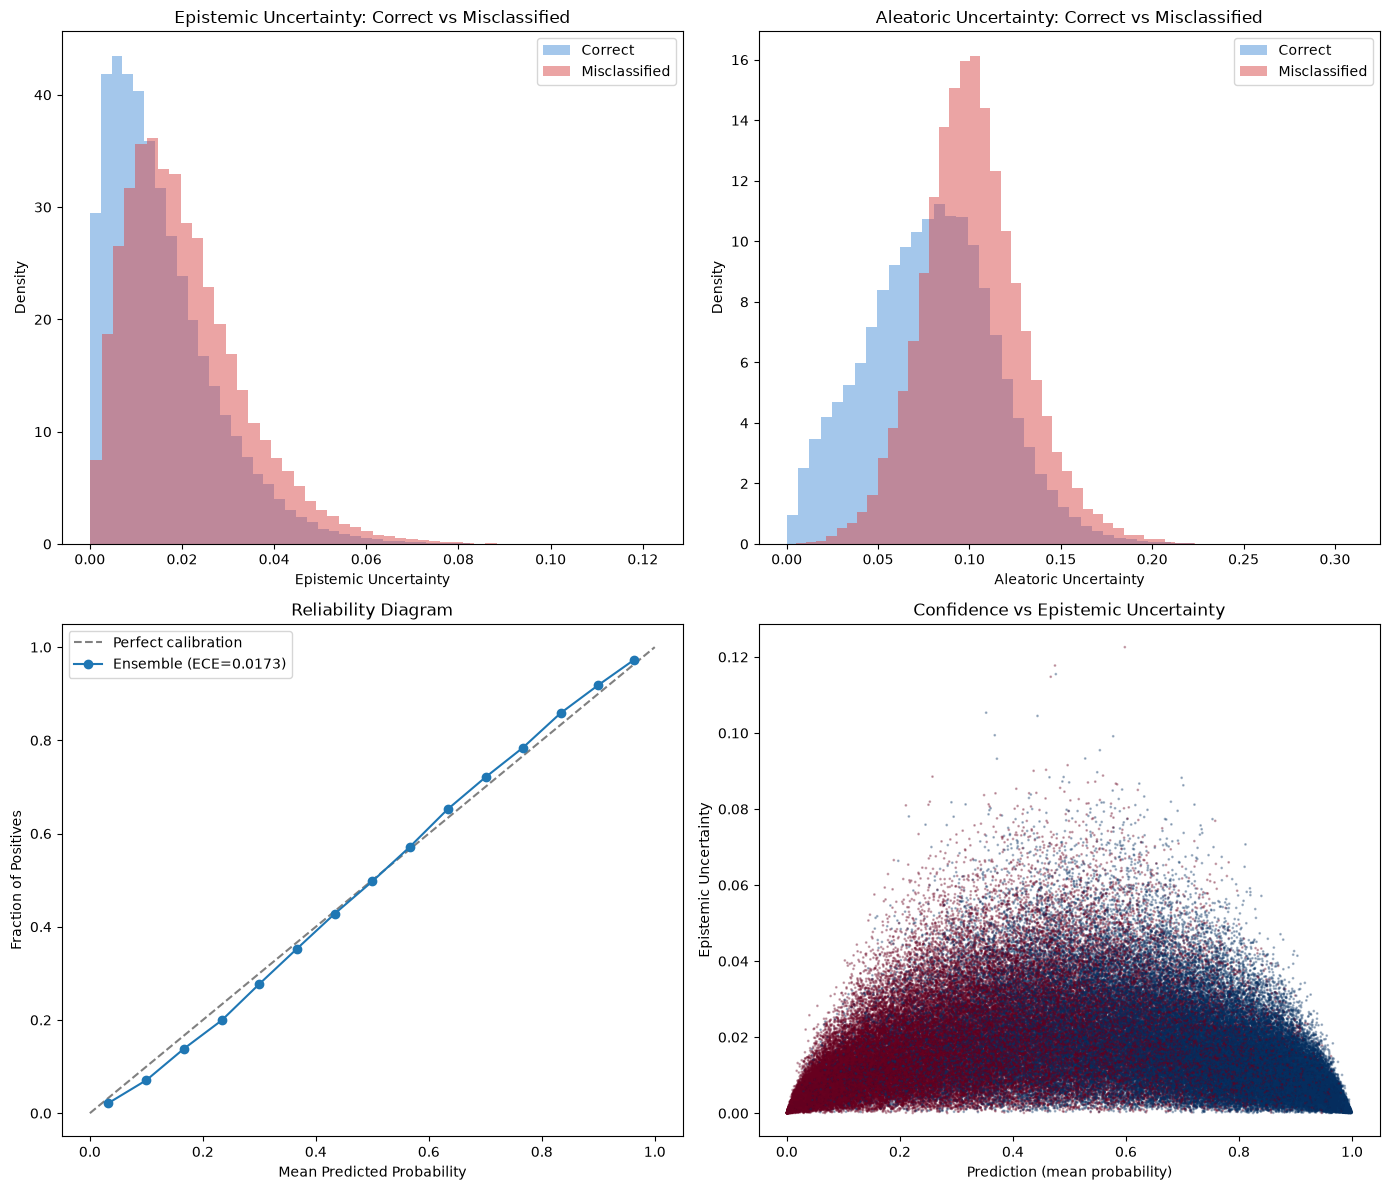

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Epistemic uncertainty: correct vs incorrect
axes[0, 0].hist(epistemic[y_test == ensemble_pred], bins=50, alpha=0.5, label="Correct", density=True, color="#4a90d9")
axes[0, 0].hist(epistemic[y_test != ensemble_pred], bins=50, alpha=0.5, label="Misclassified", density=True, color="#d94a4a")
axes[0, 0].set_xlabel("Epistemic Uncertainty")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_title("Epistemic Uncertainty: Correct vs Misclassified")
axes[0, 0].legend()

# 2. Aleatoric uncertainty: correct vs incorrect
axes[0, 1].hist(aleatoric[y_test == ensemble_pred], bins=50, alpha=0.5, label="Correct", density=True, color="#4a90d9")
axes[0, 1].hist(aleatoric[y_test != ensemble_pred], bins=50, alpha=0.5, label="Misclassified", density=True, color="#d94a4a")
axes[0, 1].set_xlabel("Aleatoric Uncertainty")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Aleatoric Uncertainty: Correct vs Misclassified")
axes[0, 1].legend()

# 3. Reliability diagram
ece, ece_bins = compute_ece(y_test, ensemble_mean, n_bins=15)
bin_accs = [b["accuracy"] for b in ece_bins]
bin_confs = [b["confidence"] for b in ece_bins]
axes[1, 0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[1, 0].plot(bin_confs, bin_accs, "o-", label=f"Ensemble (ECE={ece:.4f})")
axes[1, 0].set_xlabel("Mean Predicted Probability")
axes[1, 0].set_ylabel("Fraction of Positives")
axes[1, 0].set_title("Reliability Diagram")
axes[1, 0].legend()

# 4. Prediction confidence vs uncertainty
axes[1, 1].scatter(ensemble_mean, epistemic, s=1, alpha=0.3, c=y_test, cmap="RdBu")
axes[1, 1].set_xlabel("Prediction (mean probability)")
axes[1, 1].set_ylabel("Epistemic Uncertainty")
axes[1, 1].set_title("Confidence vs Epistemic Uncertainty")

plt.tight_layout()
plt.savefig("/Users/chris/Documents/higs-vision/figures/uncertainty_analysis.png", dpi=150)
plt.show()

In [16]:
save_uncertainty_results({
    "ensemble_mean": ensemble_mean,
    "ensemble_std": ensemble_std,
    "aleatoric": aleatoric,
    "epistemic": epistemic,
    "per_model_means": per_model_means,
    "per_model_stds": per_model_stds,
    "ensemble_pred": ensemble_pred,
}, "/Users/chris/Documents/higs-vision/results/uncertainty/test_uncertainty.npz")

import json
hypothesis_result["ece"] = ece
hypothesis_result["ensemble_roc_auc"] = ensemble_metrics["roc_auc"]

# Convert numpy types to Python types
hypothesis_result = {k: bool(v) if isinstance(v, (np.bool_,)) else float(v) if isinstance(v, (np.floating,)) else int(v) if isinstance(v, (np.integer,)) else v for k, v in hypothesis_result.items()}

with open("/Users/chris/Documents/higs-vision/results/uncertainty/hypothesis_test.json", "w") as f:
    json.dump(hypothesis_result, f, indent=2)

print("All uncertainty results saved.")

Uncertainty results saved to /Users/chris/Documents/higs-vision/results/uncertainty/test_uncertainty.npz
All uncertainty results saved.
